<a href="https://colab.research.google.com/github/jawariyakhawer/resnet./blob/main/resnet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
print("GPU available:", torch.cuda.is_available())

GPU available: True


In [ ]:
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=0)

print("Train samples:", len(trainset))
print("Test samples:", len(testset))

Using device: cuda


100%|██████████| 170M/170M [51:49<00:00, 54.8kB/s]


Train samples: 50000
Test samples: 10000


In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet(nn.Module):
    def __init__(self, num_classes=10):
        super(ResNet, self).__init__()
        self.in_channels = 16
        self.conv1 = nn.Conv2d(3, 16, 3, 1, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(16, 2, 1)
        self.layer2 = self._make_layer(32, 2, 2)
        self.layer3 = self._make_layer(64, 2, 2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        layers = [ResidualBlock(self.in_channels, out_channels, stride)]
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        return self.fc(out)

print("Classes defined successfully!")

Classes defined successfully!


In [ ]:
model = ResNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
print("Model created!")

Model created!


In [ ]:
def test():
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    accuracy = 100. * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")
    return accuracy


num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(trainloader)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")
    test()

Epoch 1/10 - Loss: 1.4589
Test Accuracy: 51.34%
Epoch 2/10 - Loss: 0.9650
Test Accuracy: 68.09%
Epoch 3/10 - Loss: 0.7676
Test Accuracy: 67.65%
Epoch 4/10 - Loss: 0.6757
Test Accuracy: 73.79%
Epoch 5/10 - Loss: 0.6069
Test Accuracy: 63.81%
Epoch 6/10 - Loss: 0.5769
Test Accuracy: 68.71%
Epoch 7/10 - Loss: 0.5349
Test Accuracy: 74.11%
Epoch 8/10 - Loss: 0.5101
Test Accuracy: 70.71%
Epoch 9/10 - Loss: 0.4970
Test Accuracy: 74.98%
Epoch 10/10 - Loss: 0.4778
Test Accuracy: 74.13%


In [ ]:
torch.save(model.state_dict(), 'resnet_cifar10.pth')
print("Model saved!")

Model saved!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

torch.save(model.state_dict(), '/content/drive/MyDrive/resnet_cifar10.pth')
print("Model saved to Google Drive!")

Mounted at /content/drive
Model saved to Google Drive!


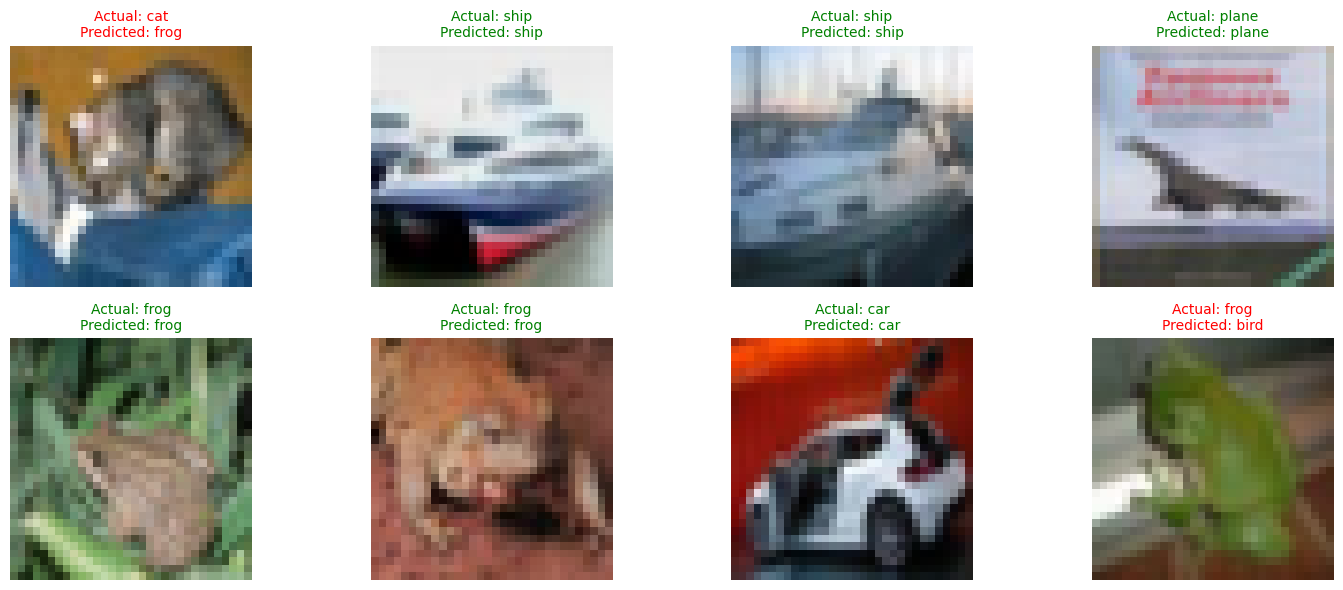

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def imshow(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# Test set se ek batch uthao
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = outputs.max(1)

fig = plt.figure(figsize=(15, 6))
for i in range(8):
    ax = fig.add_subplot(2, 4, i+1)
    imshow(images[i].cpu())
    actual = classes[labels[i].item()]
    pred = classes[predicted[i].item()]
    color = 'green' if actual == pred else 'red'
    ax.set_title(f"Actual: {actual}\nPredicted: {pred}", color=color, fontsize=10)
plt.tight_layout()
plt.show()